In [ ]:
!pip install transformers
!pip install datasets
!pip install torchaudio
!pip install jiwer
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
from transformers import pipeline
from jiwer import wer
import pandas as pd
import time

In [ ]:
dataset = load_dataset(
    "hf-internal-testing/librispeech_asr_dummy",
    "clean",
    split="validation[:5]"
)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet:   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

Dataset({
    features: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'],
    num_rows: 5
})


In [ ]:
print(dataset[0].keys())

dict_keys(['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'])


In [ ]:
asr = pipeline(
    "automatic-speech-recognition",
    model="facebook/wav2vec2-base-960h"
)

print("Model Loaded Successfully")

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Model Loaded Successfully


In [ ]:
audio = dataset[0]["audio"]["array"]

prediction = asr(audio)

print("Predicted Text:")
print(prediction["text"])

print("\nActual Text:")
print(dataset[0]["text"])

Predicted Text:
MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL

Actual Text:
MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [ ]:
reference = dataset[0]["text"]

predicted = prediction["text"]

error = wer(reference, predicted)

print("WER:", error)

WER: 0.0


In [ ]:
results = []

for i in range(5):

    audio = dataset[i]["audio"]["array"]

    prediction = asr(audio)

    predicted_text = prediction["text"]

    actual_text = dataset[i]["text"]

    error = wer(actual_text, predicted_text)

    results.append(
        [i+1,
         actual_text,
         predicted_text,
         error]
    )

print("Done")

Done


In [ ]:
df = pd.DataFrame(
    results,
    columns=[
        "Sample",
        "Actual Text",
        "Predicted Text",
        "WER"
    ]
)

df

,Sample,Actual Text,Predicted Text,WER
0,1,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CL...,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CL...,0.000000
1,2,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,0.000000
2,3,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE...,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE...,0.031250
3,4,HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIG...,HE HAS GRAVED DOUBTS WHETHER SIR FREDERICK LAY...,0.125000
4,5,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND...,LINILL'S PICTURES ARE A SORT OF UP GUARDS AND ...,0.117647


In [ ]:
average_wer = df["WER"].mean()

print("Average WER:", average_wer)

Average WER: 0.05477941176470589


In [ ]:
whisper = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small"
)

print("Whisper Loaded")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Whisper Loaded


In [ ]:
whisper_results = []

for i in range(5):

    audio = dataset[i]["audio"]["array"]

    prediction = whisper(audio)

    predicted_text = prediction["text"]

    actual_text = dataset[i]["text"]

    error = wer(actual_text, predicted_text)

    whisper_results.append(error)

print("Done")

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see re

Done


In [ ]:
whisper_avg_wer = sum(
    whisper_results
) / len(
    whisper_results
)

print("Whisper Average WER:", whisper_avg_wer)

Whisper Average WER: 1.0


In [ ]:
start = time.time()

for i in range(5):

    audio = dataset[i]["audio"]["array"]

    asr(audio)

end = time.time()

wav2vec_time = end - start

print("Wav2Vec2 Time:", wav2vec_time)

Wav2Vec2 Time: 18.669191360473633


In [ ]:
start = time.time()

for i in range(5):

    audio = dataset[i]["audio"]["array"]

    whisper(audio)

end = time.time()

whisper_time = end - start

print("Whisper Time:", whisper_time)

Whisper Time: 145.3729956150055


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Wav2Vec2",
        "Whisper"
    ],

    "WER":[
        average_wer,
        whisper_avg_wer
    ],

    "Time":[
        wav2vec_time,
        whisper_time
    ]
})

comparison

,Model,WER,Time
0,Wav2Vec2,0.054779,18.669191
1,Whisper,1.000000,145.372996


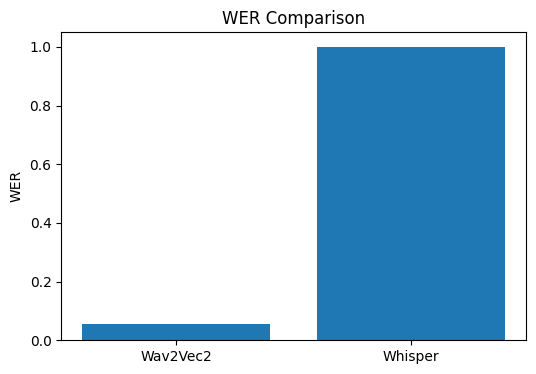

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["WER"]
)

plt.title(
    "WER Comparison"
)

plt.ylabel(
    "WER"
)

plt.show()

In [ ]:
!pip install noisereduce

In [ ]:
import noisereduce as nr

In [ ]:
audio = dataset[0]["audio"]["array"]

sample_rate = dataset[0]["audio"]["sampling_rate"]

clean_audio = nr.reduce_noise(
    y=audio,
    sr=sample_rate
)

print("Noise Reduced Successfully")

Noise Reduced Successfully


In [ ]:
prediction = asr(clean_audio)

print(prediction["text"])

MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [ ]:
original_prediction = asr(audio)

clean_prediction = asr(clean_audio)

print("Original Audio:")
print(original_prediction["text"])

print("\nNoise Reduced Audio:")
print(clean_prediction["text"])

Original Audio:
MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL

Noise Reduced Audio:
MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [ ]:
!pip install sounddevice
!pip install scipy

In [ ]:
!apt-get install libportaudio2
import sounddevice as sd
from scipy.io.wavfile import write

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libportaudio2
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 65.3 kB of archives.
After this operation, 223 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Fetched 65.3 kB in 0s (1,006 kB/s)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.1_amd64.deb ...
Unpacking libportaudio2:amd64 (19.6.0-1.1) ...
Setting up libportaudio2:amd64 (19.6.0-1.1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/l

In [ ]:
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time))

async function record() {
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});

  const recorder = new MediaRecorder(stream);
  const data = [];

  recorder.ondataavailable = event => data.push(event.data);

  recorder.start();

  await sleep(5000);

  recorder.stop();

  await new Promise(resolve => recorder.onstop = resolve);

  const audioBlob = new Blob(data, {type:'audio/wav'});
  const reader = new FileReader();

  reader.readAsDataURL(audioBlob);

  return await new Promise(resolve=>{
    reader.onloadend = ()=>resolve(reader.result);
  });
}
"""

display(Javascript(RECORD))

audio_string = output.eval_js("record()")

with open("recorded.wav","wb") as f:
    f.write(
        b64decode(
            audio_string.split(",")[1]
        )
    )

print("Recording Saved")

<IPython.core.display.Javascript object>

Recording Saved


In [ ]:
import librosa

audio, sr = librosa.load(
    "recorded.wav",
    sr=16000
)

prediction = asr(audio)

print(prediction["text"])

/tmp/ipykernel_1329/619698873.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


MY NAME IS YESHICO


/tmp/ipykernel_1329/1813664352.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


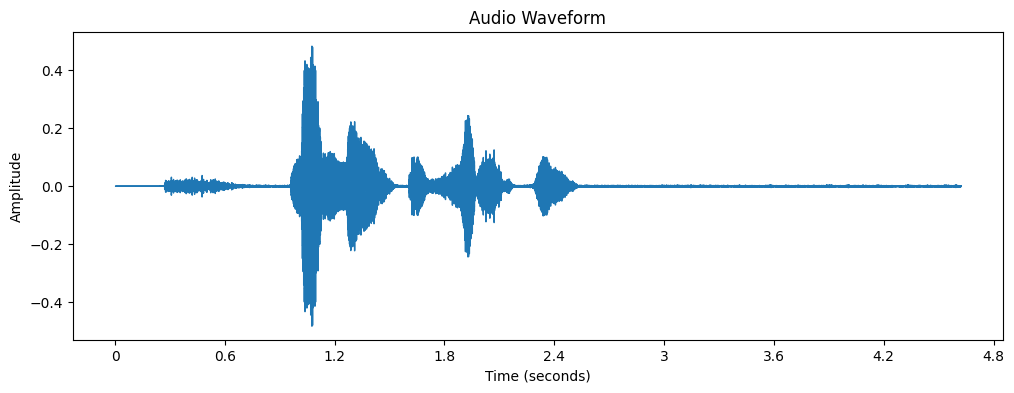

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio, sr = librosa.load(
    "recorded.wav",
    sr=16000
)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

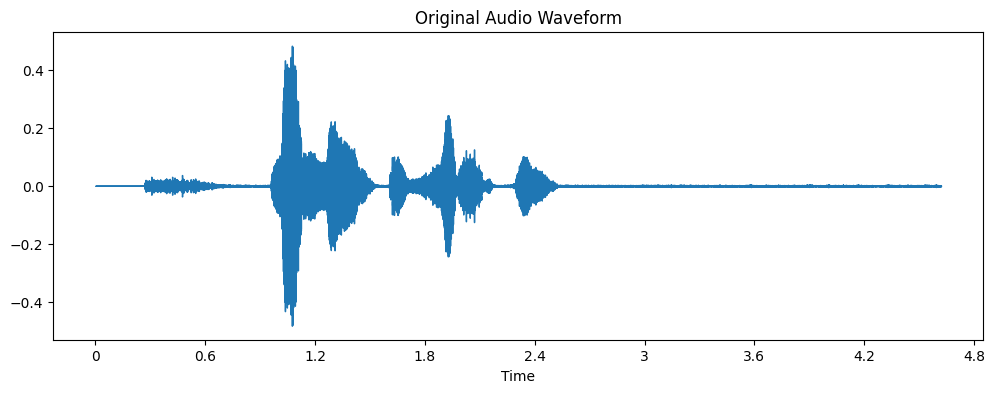

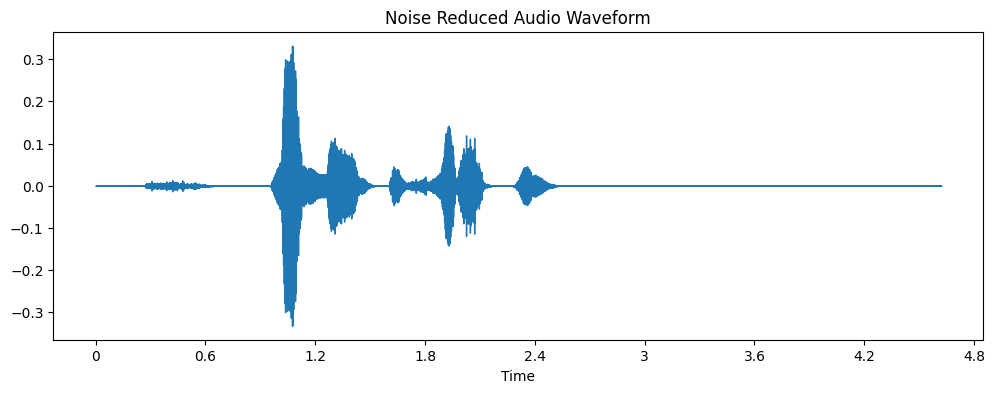

In [ ]:
import noisereduce as nr
import librosa.display
import matplotlib.pyplot as plt

clean_audio = nr.reduce_noise(
    y=audio,
    sr=sr
)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr,
)

plt.title("Original Audio Waveform")

plt.show()

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    clean_audio,
    sr=sr,
)

plt.title("Noise Reduced Audio Waveform")

plt.show()

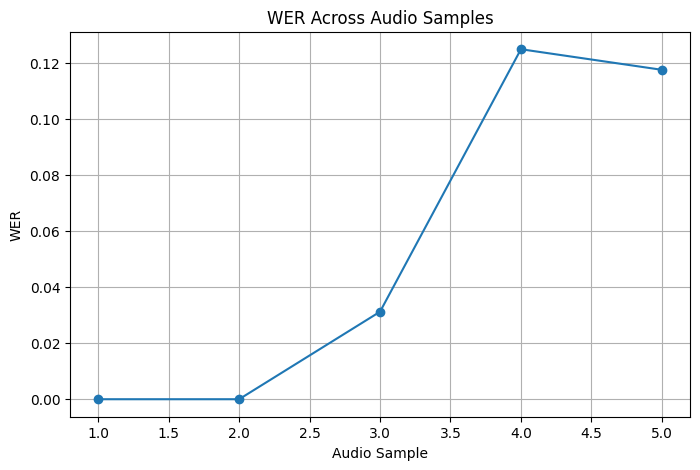

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df["Sample"],
    df["WER"],
    marker='o'
)

plt.title("WER Across Audio Samples")
plt.xlabel("Audio Sample")
plt.ylabel("WER")

plt.grid(True)

plt.show()